In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
image_path = 'dataset/calibration/calib_10x.jpg'
image = cv2.imread(image_path)

In [3]:
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

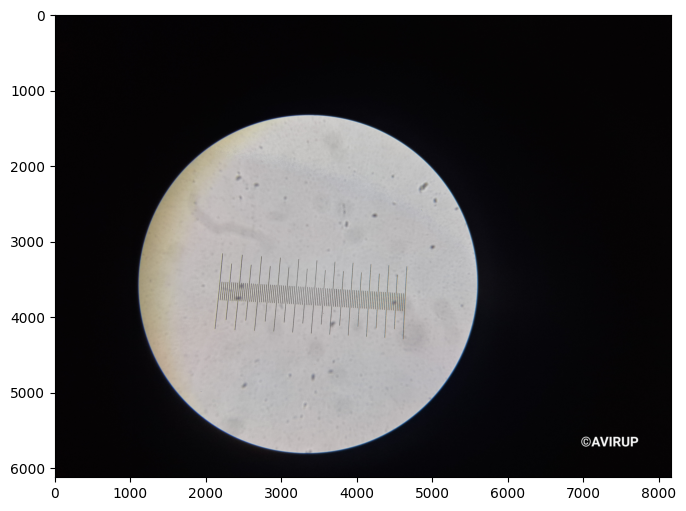

In [5]:
plt.figure(figsize=(10, 6))
plt.imshow(image_rgb)
plt.show()

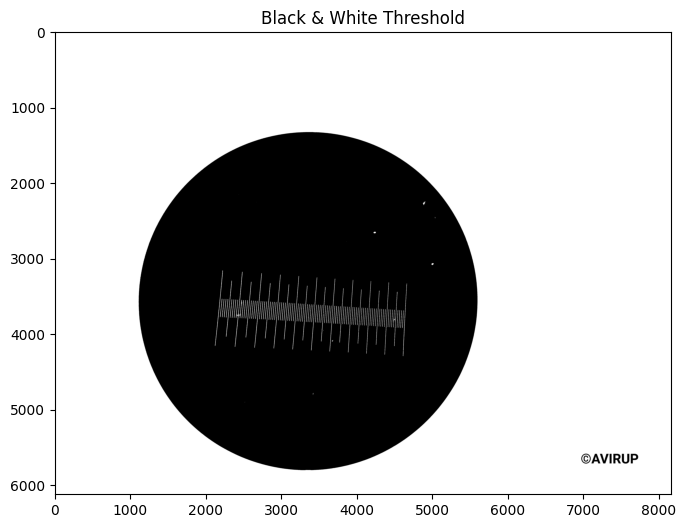

In [6]:
gray = cv2.cvtColor(image, (cv2.COLOR_BGR2GRAY))

_, thresh = cv2.threshold(gray, 120, 255, cv2.THRESH_BINARY_INV)

plt.figure(figsize=(10, 6))
plt.imshow(thresh, cmap='gray')
plt.title("Black & White Threshold")
plt.show()

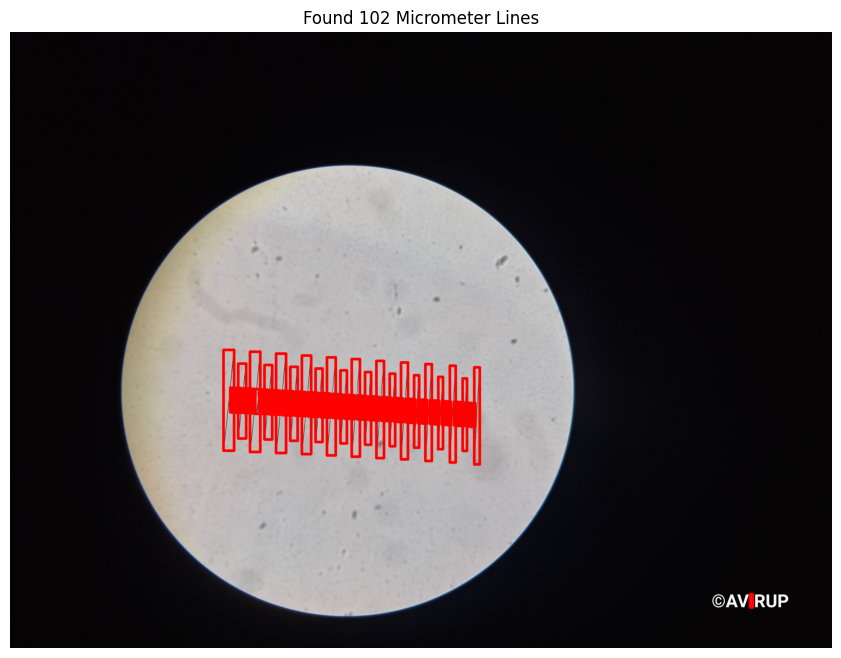

In [7]:
contours, _ = cv2.findContours(thresh, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)

output_image = image_rgb.copy()

valid_lines= []

for cnt in contours:
    x, y, w, h = cv2.boundingRect(cnt)
    if 100 < h < 4000 and h > (w * 1.5):
        valid_lines.append((x, y, w, h))

        cv2.rectangle(output_image, (x, y), (x + w, y + h), (255, 0, 0), 25)

# 5. Show the final image with the boxes
plt.figure(figsize=(12, 8))
plt.imshow(output_image)
plt.title(f"Found {len(valid_lines)} Micrometer Lines")
plt.axis('off')
plt.show()

In [ ]:
sorted_lines = sorted(valid_lines, key=lambda item: item[0])

line_centers = []
for x, y, w, h in sorted_lines:
    center_x = x + (w / 2)
    line_centers.append(center_x)

pixel_distance = []
for i in range(len(line_centers) - 1):
    gap = line_centers[i+1] - line_centers[i]
    pixel_distance.append(gap)

average_pixel_dist = np. (pixel_distance)
print(f"Average gap between lines: {average_pixel_dist:.2f} pixels")

Average gap between lines: 24.50 pixels


In [9]:
import cv2
import math

bio_image_path = 'dataset/cells/10x/ovary_img_3_10x.jpg' 
original_img = cv2.imread(bio_image_path)

if original_img is None:
    print("❌ ERROR: Could not find the image!")
else:
    um_per_pixel = 0.408 
    clicks = []

    # --- THE FIX: Lower the scale to 12% ---
    # This shrinks a 6000px tall image to 720px, fitting your laptop perfectly!
    scale_percent = 12 
    width = int(original_img.shape[1] * scale_percent / 100)
    height = int(original_img.shape[0] * scale_percent / 100)
    
    display_img = cv2.resize(original_img, (width, height), interpolation=cv2.INTER_AREA)

    def draw_ruler(event, x, y, flags, param):
        global clicks, display_img
        
        if event == cv2.EVENT_LBUTTONDOWN:
            clicks.append((x, y))
            cv2.circle(display_img, (x, y), 4, (0, 0, 255), -1) 
            cv2.imshow("Digital Ruler", display_img)
            
            if len(clicks) == 2:
                pt1 = clicks[0]
                pt2 = clicks[1]
                cv2.line(display_img, pt1, pt2, (0, 255, 0), 2)
                cv2.imshow("Digital Ruler", display_img)
                
                proxy_pixel_dist = math.sqrt((pt2[0] - pt1[0])**2 + (pt2[1] - pt1[1])**2)
                
                # Math scales the distance back up based on our 12% ratio!
                true_pixel_dist = proxy_pixel_dist * (100 / scale_percent)
                real_dist_um = true_pixel_dist * um_per_pixel
                
                print(f"Distance: {real_dist_um:.2f} µm")
                clicks = [] 

    print("Window opening! Click two points to measure. Press 'q' to close.")
    cv2.namedWindow("Digital Ruler", cv2.WINDOW_AUTOSIZE) 
    cv2.imshow("Digital Ruler", display_img)
    cv2.setMouseCallback("Digital Ruler", draw_ruler)

    while True:
        key = cv2.waitKey(1) & 0xFF
        if key == 27 or key == ord('q'):
            break

    cv2.destroyAllWindows()

Window opening! Click two points to measure. Press 'q' to close.
Distance: 648.32 µm


In [26]:
import cv2
import numpy as np

bio_image_path = 'dataset/cells/4x/ovary_img_1_4x.jpg' 
original_img = cv2.imread(bio_image_path)

if original_img is None:
    print("❌ ERROR: Could not find the image!")
else:
    um_per_pixel = 0.408 
    
    # --- PROXY DISPLAY FIX (12% scale) ---
    scale_percent = 12 
    width = int(original_img.shape[1] * scale_percent / 100)
    height = int(original_img.shape[0] * scale_percent / 100)
    display_img = cv2.resize(original_img, (width, height), interpolation=cv2.INTER_AREA)
    
    # We need a clean copy of the proxy image to draw over repeatedly
    clean_proxy = display_img.copy()

    # Variables for the Lasso state
    drawing = False
    lasso_points = []

    def draw_lasso(event, x, y, flags, param):
        global drawing, lasso_points, display_img, clean_proxy
        
        # 1. Mouse Button Pressed: Start drawing
        if event == cv2.EVENT_LBUTTONDOWN:
            drawing = True
            lasso_points = [(x, y)] # Start a new list of points
            
        # 2. Mouse Moving: Record points if the button is held down
        elif event == cv2.EVENT_MOUSEMOVE:
            if drawing:
                lasso_points.append((x, y))
                
                # Draw a green line connecting the last two points we recorded
                pt1 = lasso_points[-2]
                pt2 = lasso_points[-1]
                cv2.line(display_img, pt1, pt2, (0, 255, 0), 2)
                cv2.imshow("Lasso Tool", display_img)
                
        # 3. Mouse Button Released: Close the loop and do the math
        elif event == cv2.EVENT_LBUTTONUP:
            drawing = False
            
            # Connect the very last point back to the very first point
            if len(lasso_points) > 2:
                cv2.line(display_img, lasso_points[-1], lasso_points[0], (0, 255, 0), 2)
                cv2.imshow("Lasso Tool", display_img)
                
                # --- THE MATHEMATICS ---
                # Convert our list of points into a format OpenCV understands
                contour = np.array(lasso_points).reshape((-1, 1, 2))
                
                # Calculate Perimeter (arcLength) and Area on the proxy image
                proxy_perimeter = cv2.arcLength(contour, True)
                proxy_area = cv2.contourArea(contour)
                
                # Scale the measurements back up to the massive 8000px original size
                scale_multiplier = 100 / scale_percent
                true_px_perimeter = proxy_perimeter * scale_multiplier
                # Area scales by the SQUARE of the multiplier
                true_px_area = proxy_area * (scale_multiplier ** 2) 
                
                # Convert to physical micrometers
                real_perimeter_um = true_px_perimeter * um_per_pixel
                real_area_um2 = true_px_area * (um_per_pixel ** 2)
                
                print(f"--- MEASUREMENT COMPLETE ---")
                print(f"Perimeter: {real_perimeter_um:.2f} µm")
                print(f"Area:      {real_area_um2:.2f} µm²")

    print("Window opening! Click and drag to draw a lasso around a structure. Press 'q' to close.")
    cv2.namedWindow("Lasso Tool", cv2.WINDOW_AUTOSIZE) 
    cv2.imshow("Lasso Tool", display_img)
    cv2.setMouseCallback("Lasso Tool", draw_lasso)

    while True:
        key = cv2.waitKey(1) & 0xFF
        
        # Press 'c' to clear the drawing and start over!
        if key == ord('c'):
            display_img = clean_proxy.copy()
            cv2.imshow("Lasso Tool", display_img)
            print("Canvas cleared.")
            
        elif key == 27 or key == ord('q'):
            break

    cv2.destroyAllWindows()

Window opening! Click and drag to draw a lasso around a structure. Press 'q' to close.
--- MEASUREMENT COMPLETE ---
Perimeter: 1048.27 µm
Area:      54378.24 µm²
